<a href="https://colab.research.google.com/github/dr-dlr/drlab/blob/hackathon/hackathon_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando libs

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

# TRANSACCIONES Limpieza y revisado de datos

In [2]:
# asignando una variable al dataset
transacciones = pd.read_csv('/content/transactions.csv')

In [3]:
# revisando brevemente las columnas
transacciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119465 entries, 0 to 119464
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           119465 non-null  int64  
 1   user_id                  119465 non-null  int64  
 2   fecha_transaccion        119465 non-null  object 
 3   descripcion_transaccion  119465 non-null  object 
 4   monto_transaccion        119465 non-null  float64
 5   medio_pago               119465 non-null  object 
 6   edad                     119465 non-null  int64  
 7   sexo                     119465 non-null  object 
 8   ingreso_mensual          119465 non-null  int64  
 9   linea_credito            119465 non-null  int64  
 10  credito_utilizado        119465 non-null  int64  
 11  frecuencia_ahorro        119465 non-null  object 
 12  categoria_gasto          119465 non-null  object 
dtypes: float64(1), int64(6), object(6)
memory usage: 11.8+ MB


In [4]:
# revisando brevemente el contenido
transacciones.head(5)

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
0,1,1,2025-10-30,Soriana,1072.15,Debito,58,M,37256,30000,24132,Baja,Alimentacion
1,2,1,2025-04-22,Soriana,604.67,Debito,58,M,37256,30000,24132,Baja,Alimentacion
2,3,1,2025-04-12,Farmacias del Ahorro,1798.57,Transferencia,58,M,37256,30000,24132,Baja,Salud
3,4,1,2025-08-18,Uber,1485.49,Debito,58,M,37256,30000,24132,Baja,Transporte
4,5,1,2025-12-24,OXXO,1073.86,Efectivo,58,M,37256,30000,24132,Baja,Alimentacion


In [5]:
# Revisando las categorías en 'categoria_gasto'
print (transacciones['categoria_gasto'].unique())
print (f'Se encuentran ausentes dos categorías: "Vivienda y Educación')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento']
Se encuentran ausentes dos categorías: "Vivienda y Educación


In [6]:
# Añadiendo las categorías que faltaban de acuerdo con el desafío (educación y vivienda)

import numpy as np
import random

# Obtener todos los IDs de usuario únicos
unique_users = transacciones['user_id'].unique()

new_rows = []

for user in unique_users:
    # Datos base del usuario (asumiendo que edad, sexo, ingreso, etc. son constantes por usuario)
    user_info = transacciones[transacciones['user_id'] == user].iloc[0]

    # 1. Transacción de Vivienda
    new_rows.append({
        'transaction_id': 0, # Se resetearán después
        'user_id': user,
        'fecha_transaccion': '2025-06-15',
        'descripcion_transaccion': random.choice(['Home Depot', 'Interceramic']),
        'monto_transaccion': round(random.uniform(500, 5000), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Transferencia']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Vivienda'
    })

    # 2. Transacción de Educación
    new_rows.append({
        'transaction_id': 0,
        'user_id': user,
        'fecha_transaccion': '2025-07-20',
        'descripcion_transaccion': random.choice(['Librerías Gandhi', 'Proveedora Escolar']),
        'monto_transaccion': round(random.uniform(200, 1500), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Efectivo']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Educacion'
    })

# Crear DataFrame con nuevas filas y concatenar
df_nuevos = pd.DataFrame(new_rows)
transacciones = pd.concat([transacciones, df_nuevos], ignore_index=True)

# Recalcular transaction_id para que sea único
transacciones['transaction_id'] = range(1, len(transacciones) + 1)

print(f'Se añadieron {len(df_nuevos)} nuevas filas.')
display(transacciones.tail(3))

Se añadieron 6000 nuevas filas.


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
125462,125463,2999,2025-07-20,Proveedora Escolar,1116.87,Efectivo,54,M,41035,30000,23407,Alta,Educacion
125463,125464,3000,2025-06-15,Home Depot,3118.59,Transferencia,46,F,58563,30000,13664,Media,Vivienda
125464,125465,3000,2025-07-20,Proveedora Escolar,597.94,Credito,46,F,58563,30000,13664,Media,Educacion


In [7]:
# ya aparecen las categorías que faltaban en el set original

print (transacciones['categoria_gasto'].unique())
print (f'Ya se encuentran las 8 categorías')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento' 'Vivienda' 'Educacion']
Ya se encuentran las 8 categorías


In [8]:
transacciones.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago', 'edad',
       'sexo', 'ingreso_mensual', 'linea_credito', 'credito_utilizado',
       'frecuencia_ahorro', 'categoria_gasto'],
      dtype='object')

In [9]:
transacciones.to_csv('transacciones_ok.csv', index=False)

In [10]:
# Eliminando las variables que no sirven para este dataset

transacciones_ok = transacciones.drop(['edad', 'sexo', 'ingreso_mensual', 'linea_credito', 'credito_utilizado', 'frecuencia_ahorro'], axis = 1)

In [11]:
transacciones_ok.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago',
       'categoria_gasto'],
      dtype='object')

In [12]:
# Pasando todo el texto a minúsculas

text_columns = transacciones_ok.select_dtypes(include=['object']).columns

for col in text_columns:
    transacciones_ok[col] = transacciones_ok[col].str.lower()

display(transacciones_ok.head())

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,soriana,1072.15,debito,alimentacion
1,2,1,2025-04-22,soriana,604.67,debito,alimentacion
2,3,1,2025-04-12,farmacias del ahorro,1798.57,transferencia,salud
3,4,1,2025-08-18,uber,1485.49,debito,transporte
4,5,1,2025-12-24,oxxo,1073.86,efectivo,alimentacion


In [13]:
transacciones_ok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125465 entries, 0 to 125464
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           125465 non-null  int64  
 1   user_id                  125465 non-null  int64  
 2   fecha_transaccion        125465 non-null  object 
 3   descripcion_transaccion  125465 non-null  object 
 4   monto_transaccion        125465 non-null  float64
 5   medio_pago               125465 non-null  object 
 6   categoria_gasto          125465 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 6.7+ MB


In [14]:
transacciones_ok.isnull().sum()

,0
transaction_id,0
user_id,0
fecha_transaccion,0
descripcion_transaccion,0
monto_transaccion,0
medio_pago,0
categoria_gasto,0


In [15]:
transacciones_ok.duplicated().sum()

np.int64(0)

NO EXISTEN DATOS NULOS, DUPLICADOS, EN MAYÚSCULAS NI FALTANTES

# TRANSACCIONES Exploración de datos

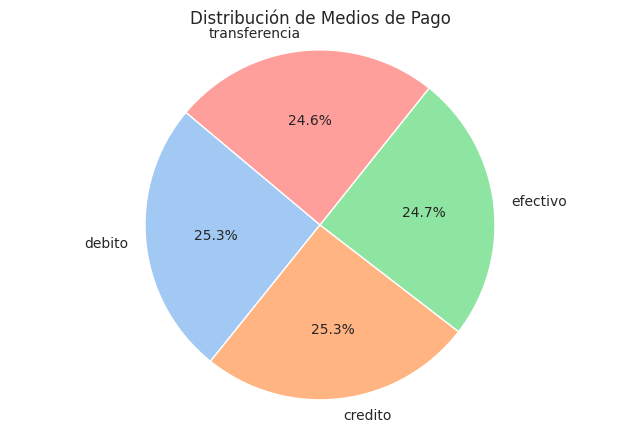

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

distribucion_pagos = transacciones_ok['medio_pago'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.pie(distribucion_pagos,
        labels=distribucion_pagos.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribución de Medios de Pago')
plt.axis('equal')
plt.show()

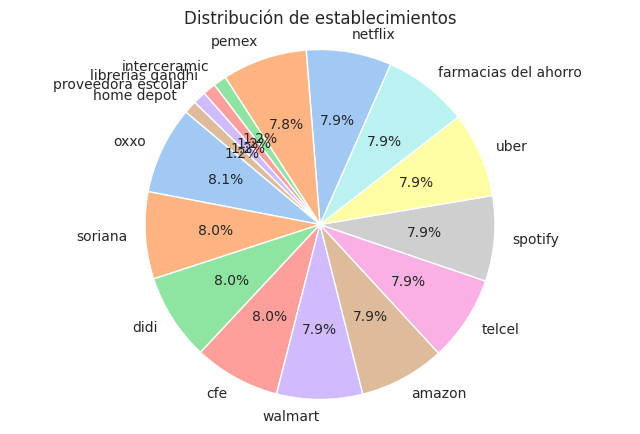

In [17]:
distribucion_negocios = transacciones_ok['descripcion_transaccion'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.pie(distribucion_negocios,
        labels=distribucion_negocios.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribución de establecimientos')
plt.axis('equal')
plt.show()

# CLIENTES Limpieza y revisado de datos

In [18]:
clientes = pd.read_csv('/content/users.csv')
clientes.head(3)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,M,Soltero,2,0,37256,30000,24132,Baja,1117.68,En riesgo
1,2,31,M,Divorciado,1,1,61354,30000,3090,Baja,1840.62,En observacion
2,3,29,F,Divorciado,1,1,28866,15000,6267,Alta,6350.52,En observacion


In [19]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                3000 non-null   int64  
 1   edad                   3000 non-null   int64  
 2   sexo                   3000 non-null   object 
 3   estado_civil           3000 non-null   object 
 4   numero_hijos           3000 non-null   int64  
 5   empleo_formal          3000 non-null   int64  
 6   ingreso_mensual        3000 non-null   int64  
 7   linea_credito          3000 non-null   int64  
 8   credito_utilizado      3000 non-null   int64  
 9   frecuencia_ahorro      3000 non-null   object 
 10  monto_promedio_ahorro  3000 non-null   float64
 11  perfil_financiero      3000 non-null   object 
dtypes: float64(1), int64(7), object(4)
memory usage: 281.4+ KB


In [20]:
clientes.columns

Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')

In [21]:
print (f'Las columnas de transacciones son {transacciones_ok.columns}')
print (f'Las columnas de clientes son {clientes.columns}')

Las columnas de transacciones son Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago',
       'categoria_gasto'],
      dtype='object')
Las columnas de clientes son Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')


In [22]:
text_columns_clientes = clientes.select_dtypes(include=['object']).columns

for col in text_columns_clientes:
    clientes[col] = clientes[col].str.lower()

display(clientes.head())

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,m,soltero,2,0,37256,30000,24132,baja,1117.68,en riesgo
1,2,31,m,divorciado,1,1,61354,30000,3090,baja,1840.62,en observacion
2,3,29,f,divorciado,1,1,28866,15000,6267,alta,6350.52,en observacion
3,4,19,f,unión libre,3,0,69261,30000,20390,media,6926.10,en riesgo
4,5,62,m,divorciado,0,0,45268,80000,62746,media,4526.80,en riesgo


In [23]:
clientes.isnull().sum()

,0
user_id,0
edad,0
sexo,0
estado_civil,0
numero_hijos,0
empleo_formal,0
ingreso_mensual,0
linea_credito,0
credito_utilizado,0
frecuencia_ahorro,0


In [24]:
clientes.duplicated().sum()

np.int64(0)

NO EXISTEN VALORES NULOS NI DUPLICADOS EN EL DATASET DE CLIENTES

# UNIENDO ambos datasets

In [25]:
# Realizando el merge de los datasets por user_id
df_final = pd.merge(transacciones_ok, clientes, on='user_id', how='inner')

# Verificando el resultado
print(f'Dimensiones del nuevo dataset: {df_final.shape}')
display(df_final.head(1))

Dimensiones del nuevo dataset: (125465, 18)


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,1,2025-10-30,soriana,1072.15,debito,alimentacion,58,m,soltero,2,0,37256,30000,24132,baja,1117.68,en riesgo


# Matriz de correlación entre variables usando Spearman

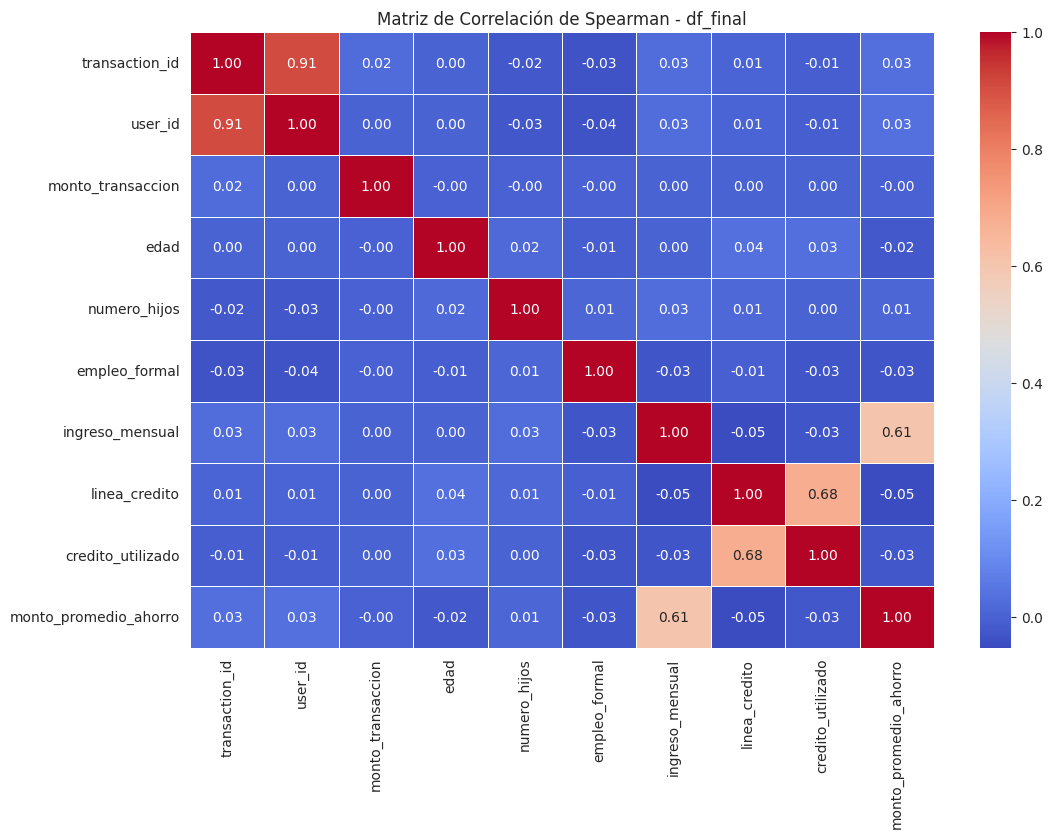

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo las columnas numéricas para la correlación
columnas_numericas = df_final.select_dtypes(include=['float64', 'int64'])

# Calculamos la matriz de correlación de Spearman
corr_matrix = columnas_numericas.corr(method='spearman')

# Configuramos el estilo visual
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación de Spearman - df_final')
plt.show()

# ENTRENAMIENTO TRANSACCIONES (NLP)

,Modelo,Acc Train,Acc Test,Precision Macro,Recall Macro,F1-Score Macro
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Linear SVC,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0



--- MEJOR MODELO SELECCIONADO: Logistic Regression ---

Classification Report:
                 precision    recall  f1-score   support

   alimentacion       1.00      1.00      1.00      6042
        compras       1.00      1.00      1.00      1987
      educacion       1.00      1.00      1.00       600
entretenimiento       1.00      1.00      1.00      3953
          salud       1.00      1.00      1.00      1975
      servicios       1.00      1.00      1.00      3981
     transporte       1.00      1.00      1.00      5955
       vivienda       1.00      1.00      1.00       600

       accuracy                           1.00     25093
      macro avg       1.00      1.00      1.00     25093
   weighted avg       1.00      1.00      1.00     25093



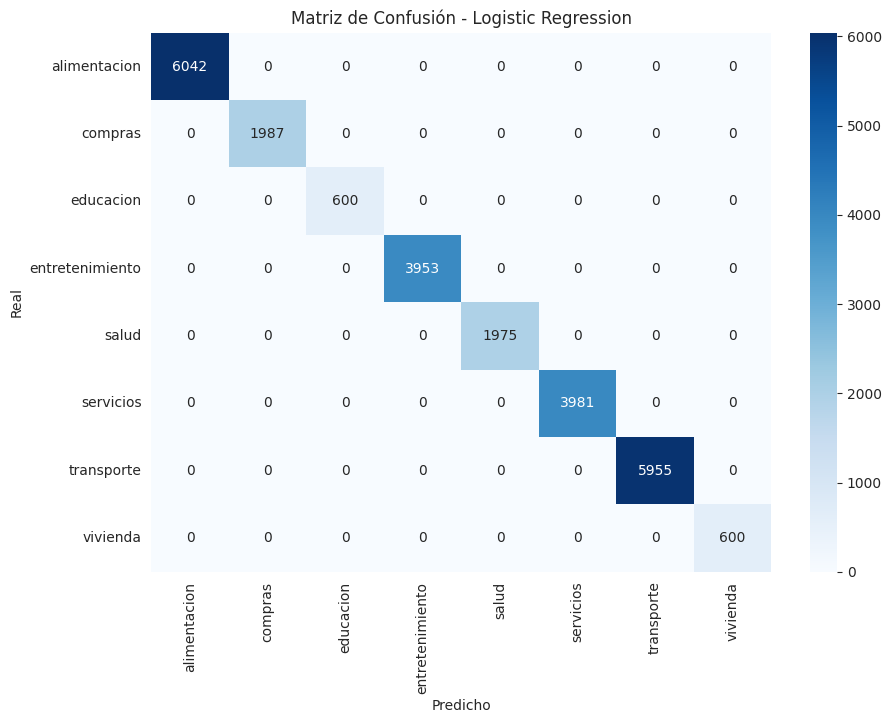


Pipeline exportado exitosamente como 'modelo_clasificacion_transacciones.pkl'


In [27]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar variables
X = transacciones_ok[['descripcion_transaccion', 'monto_transaccion']]
y = transacciones_ok['categoria_gasto']

# 2. División de datos con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Preprocesamiento: ColumnTransformer
# Vectorizamos el texto y escalamos el monto numérico
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(), 'descripcion_transaccion'),
        ('scaler', StandardScaler(), ['monto_transaccion'])
    ]
)

# 4. Definición de modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC': LinearSVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
best_f1 = 0
best_model_name = ""
best_pipeline = None

# 5. Entrenamiento y evaluación comparativa
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Entrenar
    pipeline.fit(X_train, y_train)

    # Predecir
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='macro')
    precision = precision_score(y_test, y_pred_test, average='macro')
    recall = recall_score(y_test, y_pred_test, average='macro')

    results.append({
        'Modelo': name,
        'Acc Train': acc_train,
        'Acc Test': acc_test,
        'Precision Macro': precision,
        'Recall Macro': recall,
        'F1-Score Macro': f1
    })

    # Selección del mejor modelo
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipeline = pipeline

# 6. Mostrar tabla comparativa
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1-Score Macro', ascending=False))

# 7. Evaluación detallada del mejor modelo
print(f"\n--- MEJOR MODELO SELECCIONADO: {best_model_name} ---")
y_final_pred = best_pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_final_pred))

# Matriz de Confusión
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_pipeline.classes_,
            yticklabels=best_pipeline.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# 8. Serialización del Pipeline completo
# Es vital guardar el pipeline que incluye el TfidfVectorizer para la API en Spring Boot
joblib.dump(best_pipeline, 'modelo_clasificacion_transacciones.pkl')
print(f"\nPipeline exportado exitosamente como 'modelo_clasificacion_transacciones.pkl'")

# ENTRENAMIENTO PERFIL FINANCIERO

Entrenando y optimizando el modelo...

Mejores Hiperparámetros: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}

--- Métricas de Evaluación ---
Accuracy: 0.9667
F1-Score Macro: 0.9627
Precision Macro: 0.9756
Recall Macro: 0.9513

Classification Report:
                precision    recall  f1-score   support

en observacion       0.97      0.96      0.97       323
     en riesgo       0.95      0.98      0.97       243
     saludable       1.00      0.91      0.95        34

      accuracy                           0.97       600
     macro avg       0.98      0.95      0.96       600
  weighted avg       0.97      0.97      0.97       600



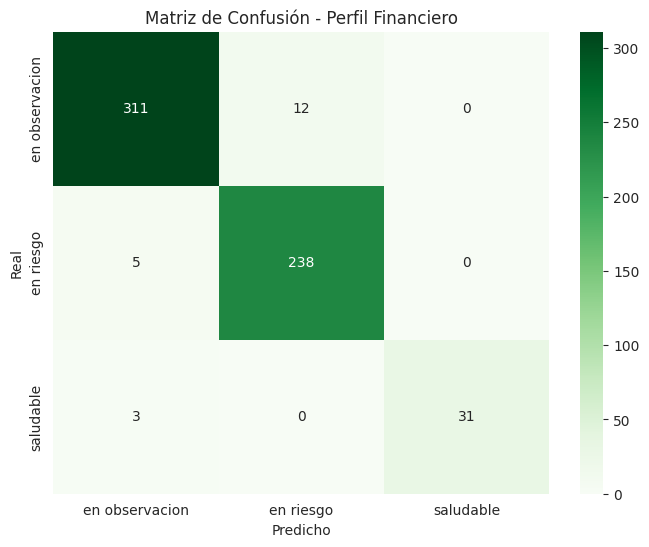

In [28]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# 1. Separar X e y
X = clientes.drop(['user_id', 'perfil_financiero'], axis=1)
y = clientes['perfil_financiero']

# 2. Identificar automáticamente variables numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Construir ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 4. Construir Pipeline completo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 5. Dividir datos (Estratificación para mantener proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Optimización de hiperparámetros con RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

print("Entrenando y optimizando el modelo...")
random_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_model = random_search.best_estimator_

# 7. Evaluación
y_pred = best_model.predict(X_test)

print(f"\nMejores Hiperparámetros: {random_search.best_params_}")
print("\n--- Métricas de Evaluación ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Precision Macro: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall Macro: {recall_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Matriz de Confusión - Perfil Financiero')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

/tmp/ipykernel_2763/2860280229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_imp, palette='viridis')


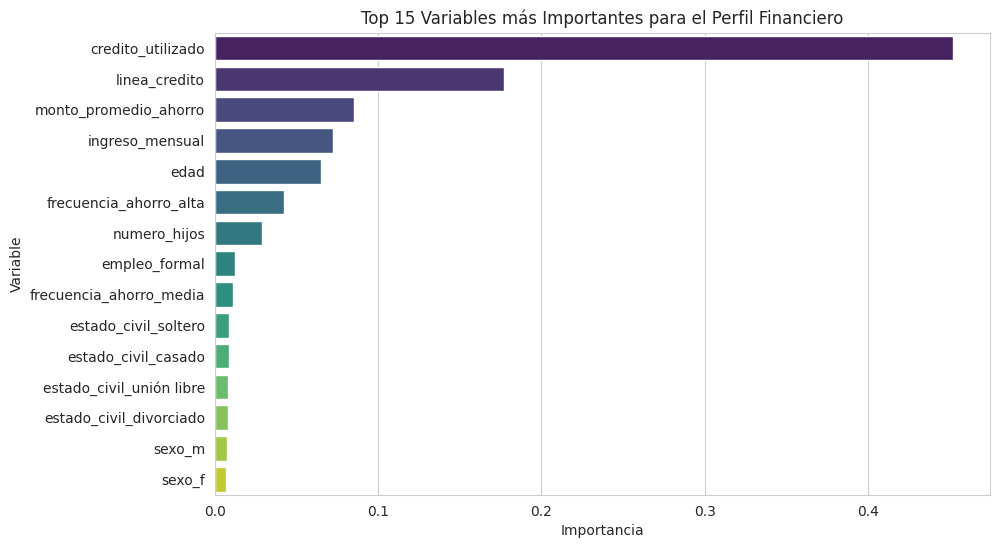

Pipeline completo serializado como 'modelo_perfil_financiero.pkl'


In [29]:
def plot_feature_importance(model, numeric_features, categorical_features):
    # Obtener nombres de columnas tras OneHotEncoder
    ohe_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numeric_features + ohe_features.tolist()

    # Extraer importancias
    importances = model.named_steps['classifier'].feature_importances_

    # Crear DataFrame y graficar
    feature_imp = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
    feature_imp = feature_imp.sort_values(by='Importancia', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Variable', data=feature_imp, palette='viridis')
    plt.title('Top 15 Variables más Importantes para el Perfil Financiero')
    plt.show()

    return feature_imp

# Mostrar importancia
feat_imp_df = plot_feature_importance(best_model, numeric_features, categorical_features)

# 9. Serialización
joblib.dump(best_model, 'modelo_perfil_financiero.pkl')
print("Pipeline completo serializado como 'modelo_perfil_financiero.pkl'")

In [30]:
!pip install shap -q

Visualizando el impacto SHAP (Summary Plot):


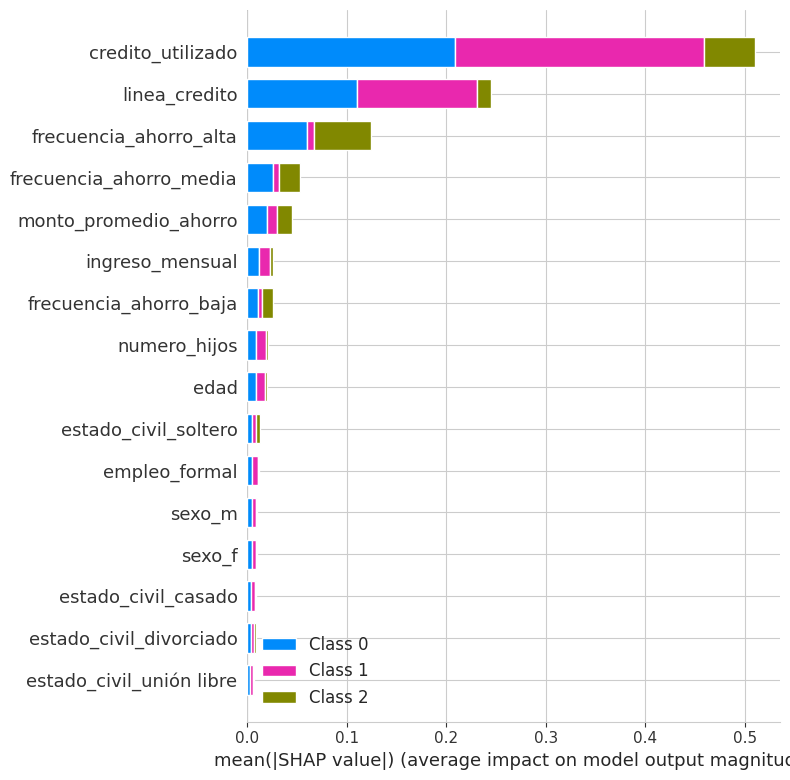

In [31]:
import shap

# 1. Preparar los datos transformados
# Extraemos el preprocesador y el clasificador del mejor modelo
preprocessor = best_model.named_steps['preprocessor']
clf = best_model.named_steps['classifier']

# Transformamos una muestra de test para el análisis (SHAP es intensivo en cómputo)
X_test_transformed = preprocessor.transform(X_test)

# Obtener nombres de las columnas transformadas para legibilidad
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + ohe_features.tolist()

# 2. Inicializar el explicador de SHAP (TreeExplainer para Random Forest)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed)

# 3. Visualización
# Mostramos el impacto de las variables para todas las clases
print("Visualizando el impacto SHAP (Summary Plot):")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

In [32]:
for i, label in enumerate(best_model.classes_):
    print(f"Clase {i}: {label}")

Clase 0: en observacion
Clase 1: en riesgo
Clase 2: saludable


### Análisis de Impacto SHAP

El gráfico anterior nos permite entender:
1. **Magnitud**: Qué tan fuerte es el impacto de cada variable en la decisión final.
2. **Distribución por Clase**: Los colores representan cómo cada variable contribuye a las diferentes etiquetas del perfil financiero.

Generalmente, verás que `credito_utilizado` y `monto_promedio_ahorro` dominan la explicación, confirmando que el comportamiento de gasto y reserva es lo que más separa a un usuario saludable de uno en riesgo.

### Prueba de Predicción con Datos Nuevos
En esta sección, utilizaremos los Pipelines cargados (o los objetos `best_pipeline` y `best_model` que tenemos en memoria) para clasificar datos que no estaban en el dataset original.

In [34]:
import pandas as pd

# --- 1. Probar Modelo A (Clasificación de Transacciones) ---
print("--- Predicción Modelo A (Transacciones) ---")
# Probamos con términos que el modelo conoce bien por el entrenamiento
nueva_transaccion = pd.DataFrame({
    'descripcion_transaccion': ['viaje nocturno uber', 'suscripción mensual netflix', 'compra en soriana'],
    'monto_transaccion': [250.0, 189.0, 1200.50]
})

prediccion_a = best_pipeline.predict(nueva_transaccion)
for desc, cat in zip(nueva_transaccion['descripcion_transaccion'], prediccion_a):
    print(f"Transacción: '{desc}' -> Categoría Predicha: {cat.upper()}")

# --- 2. Probar Modelo B (Perfil Financiero) ---
print("\n--- Predicción Modelo B (Perfil Financiero) ---")
# Cliente con alto uso de crédito para ver si cambia a 'EN RIESGO'
cliente_riesgo = pd.DataFrame({
    'edad': [25],
    'sexo': ['f'],
    'estado_civil': ['soltero'],
    'numero_hijos': [0],
    'empleo_formal': [1],
    'ingreso_mensual': [20000],
    'linea_credito': [10000],
    'credito_utilizado': [9500],  # 95% de uso
    'frecuencia_ahorro': ['baja'],
    'monto_promedio_ahorro': [100.0]
})

prediccion_b = best_model.predict(cliente_riesgo)
print(f"Cliente (Alto Riesgo) -> Perfil Predicho: {prediccion_b[0].upper()}")

--- Predicción Modelo A (Transacciones) ---
Transacción: 'viaje nocturno uber' -> Categoría Predicha: TRANSPORTE
Transacción: 'suscripción mensual netflix' -> Categoría Predicha: ENTRETENIMIENTO
Transacción: 'compra en soriana' -> Categoría Predicha: ALIMENTACION

--- Predicción Modelo B (Perfil Financiero) ---
Cliente (Alto Riesgo) -> Perfil Predicho: EN RIESGO
